In [1]:
pip install pystan

  Using cached pystan-3.10.1-py3-none-any.whl.metadata (3.6 kB)
  Using cached clikit-0.6.2-py2.py3-none-any.whl.metadata (1.6 kB)
INFO: pip is looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.10.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.9.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.9.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.8.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pystan-3.7.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.6.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.5.0-py3-none-any.whl.metadata (3.7 kB)
INFO: pip is still looking at multiple versions of pystan to determine which version is compatible with other requirements. This could take a while.
  Using cached pystan-3.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached pystan-3.3.0-py3-none-any.whl.metadata (3.6 kB)
  Using c

  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [23 lines of output]
  Traceback (most recent call last):
    File "C:\Users\Sameen\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
      ~~~~^^
    File "C:\Users\Sameen\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Sameen\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      return hook(config_settings)
    File "C:\Users\Sameen\AppData\Local\Temp\pip-build-env-a9darw19\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_build_wheel
      return self._get_build_requires(config_settings, req

In [2]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [23]:
from prophet import Prophet
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

import plotly.graph_objs as go
import plotly.offline as py

In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/airline-passengers.csv"
df = pd.read_csv(url)

In [5]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Rename the columns

In [6]:
df = df.rename(columns = {"Passengers":"y", "Month":"ds"})

In [7]:
df.head()

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# Saving the copy of y

In [8]:
df["y_copy"] = df["y"]

In [9]:
df.head()

,ds,y,y_copy
0,1949-01,112,112
1,1949-02,118,118
2,1949-03,132,132
3,1949-04,129,129
4,1949-05,121,121


# FB Prophet ma hm stationary test wagera nai krtay, koi fark nhi parta data ts ho ya na ho

### But this step is lazmi

In [10]:
df['y'] = np.log(df['y'])

In [11]:
df.head()

,ds,y,y_copy
0,1949-01,4.718499,112
1,1949-02,4.770685,118
2,1949-03,4.882802,132
3,1949-04,4.859812,129
4,1949-05,4.795791,121


# Applying the model

In [12]:
fb = Prophet()
fb.add_country_holidays(country_name='US')
fb.fit(df)

14:26:38 - cmdstanpy - INFO - Chain [1] start processing
14:26:38 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
'''     'year': 'A',
        'quarter': 'Q',
        'month': 'ME',
        'day': 'D',
        'hour': 'H',
        'minute': 'T',
        'second': 'S',
        'millisecond': 'L',
        'microsecond': 'U',
        'nanosecond': 'N'}
'''

"     'year': 'A',\n        'quarter': 'Q',\n        'month': 'ME',\n        'day': 'D',\n        'hour': 'H',\n        'minute': 'T',\n        'second': 'S',\n        'millisecond': 'L',\n        'microsecond': 'U',\n        'nanosecond': 'N'}\n"

# Make future predictions

In [14]:
forecast_Data = fb.make_future_dataframe(periods = 12, freq = 'ME')
forecast = fb.predict(forecast_Data)

In [15]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Armistice Day,Armistice Day_lower,Armistice Day_upper,Christmas Day,...,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,4.806722,4.667170,4.756579,4.806722,4.806722,0.0,0.0,0.0,0.0,...,-0.049168,-0.049168,-0.049168,-0.044514,-0.044514,-0.044514,0.0,0.0,0.0,4.713040
1,1949-02-01,4.812200,4.661717,4.751944,4.812200,4.812200,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,-0.105133,-0.105133,-0.105133,0.0,0.0,0.0,4.707067
2,1949-03-01,4.817148,4.790918,4.880438,4.817148,4.817148,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.017565,0.017565,0.017565,0.0,0.0,0.0,4.834712
3,1949-04-01,4.822626,4.770496,4.855452,4.822626,4.822626,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,-0.006936,-0.006936,-0.006936,0.0,0.0,0.0,4.815690
4,1949-05-01,4.827927,4.767361,4.857277,4.827927,4.827927,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,-0.013461,-0.013461,-0.013461,0.0,0.0,0.0,4.814466


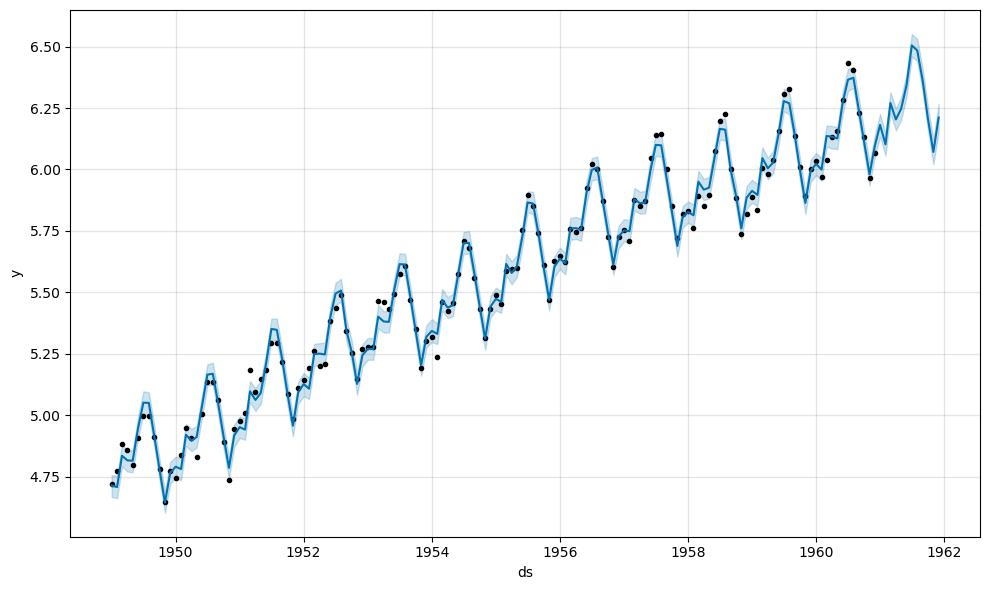

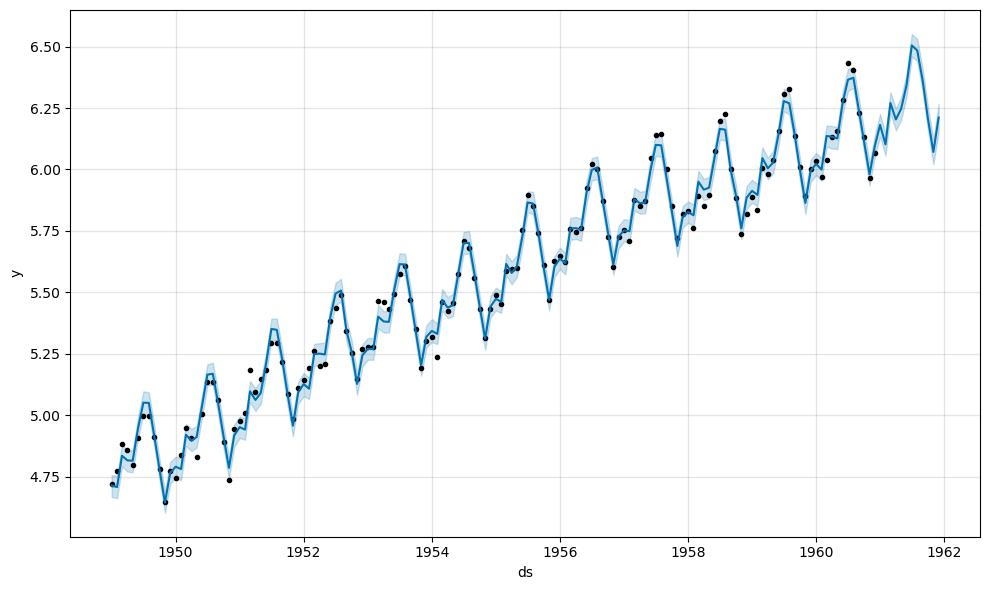

In [16]:
fb.plot(forecast)

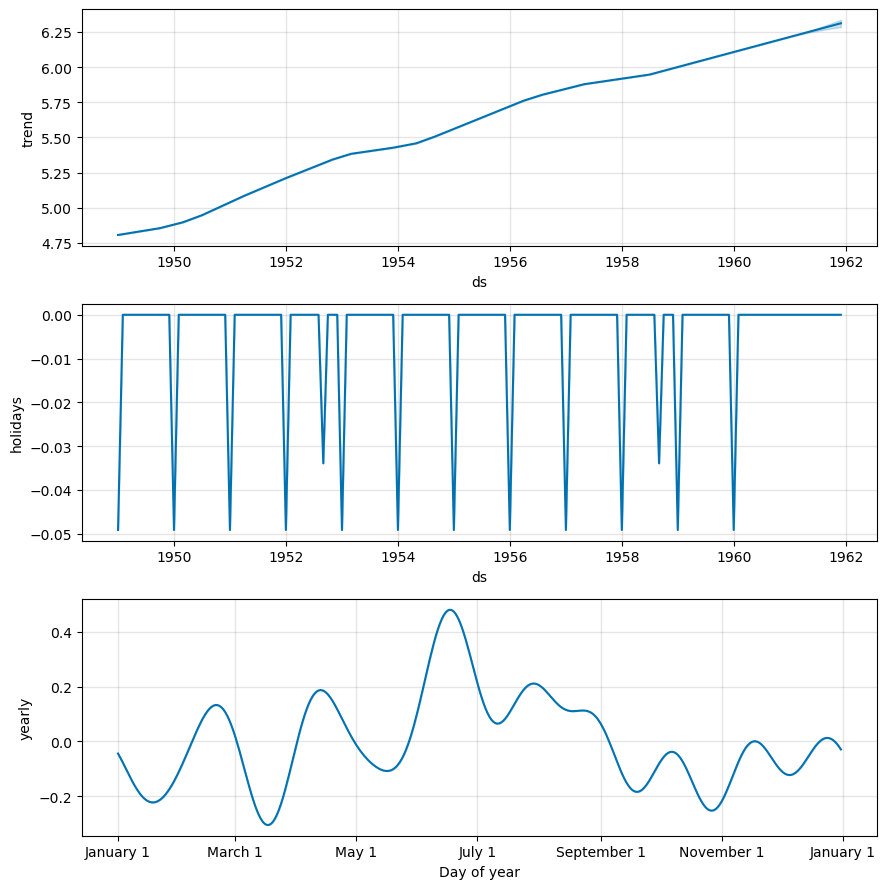

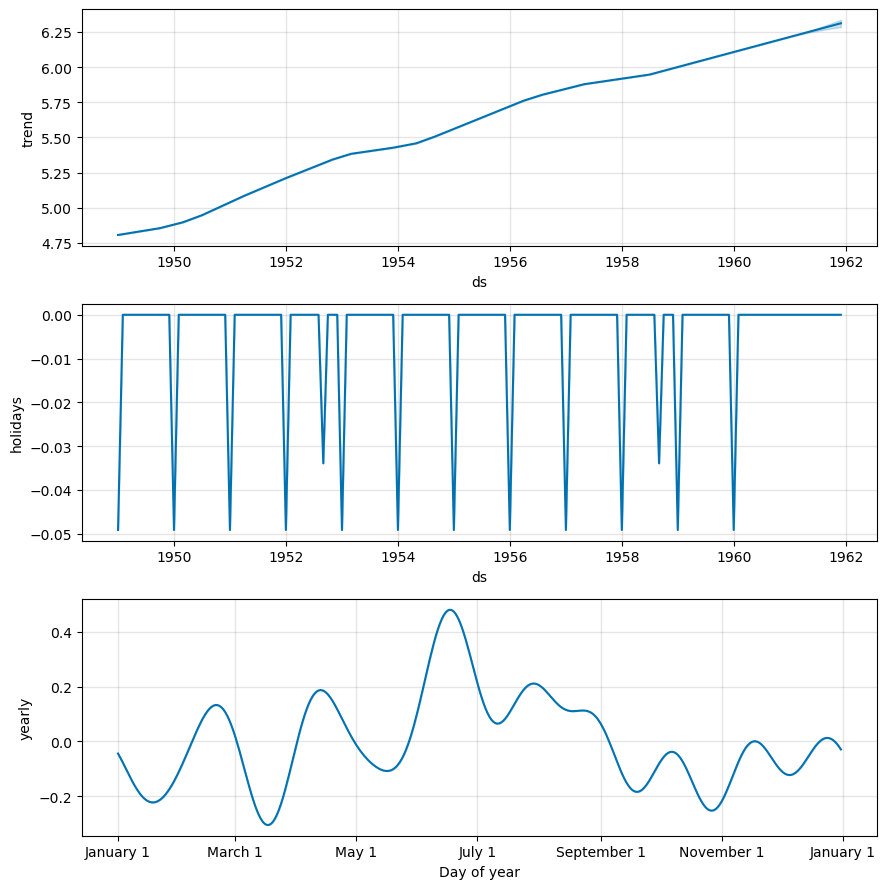

In [17]:
fb.plot_components(forecast)

In [18]:
forecast_data_orig = forecast # make sure we save the original forecast data
forecast_data_orig['yhat'] = np.exp(forecast_data_orig['yhat'])
forecast_data_orig['yhat_lower'] = np.exp(forecast_data_orig['yhat_lower'])
forecast_data_orig['yhat_upper'] = np.exp(forecast_data_orig['yhat_upper'])

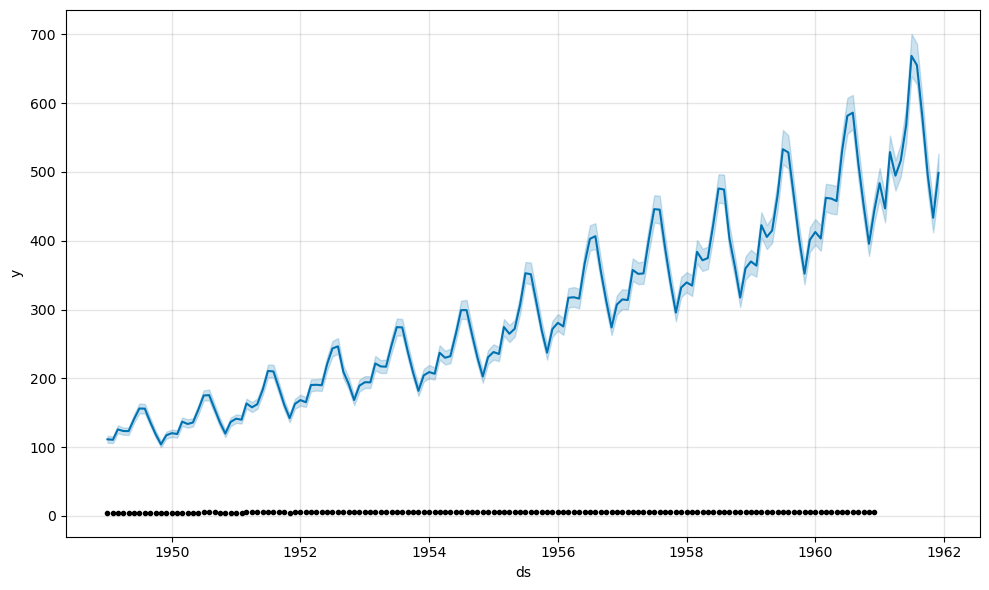

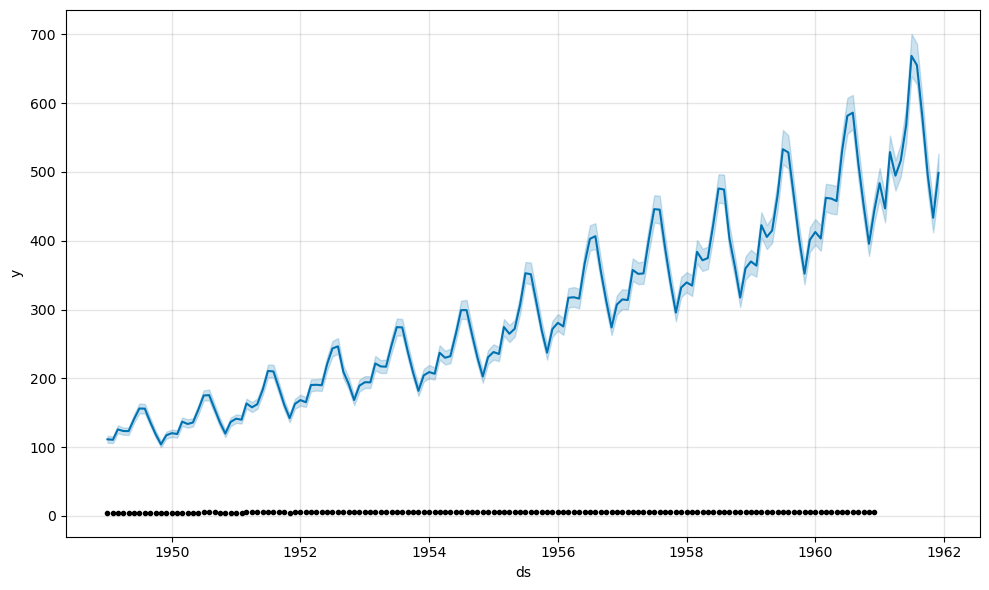

In [19]:
fb.plot(forecast_data_orig)

In [21]:
df['y_log']=df['y'] #copy the log-transformed data to another column
df['y']=df['y_copy']

In [22]:
final_df = pd.DataFrame(forecast_data_orig)

In [25]:
actual_chart = go.Scatter(y=df["y_copy"], name= 'Actual')
predict_chart = go.Scatter(y=final_df["yhat"], name= 'Predicted')
predict_chart_upper = go.Scatter(y=final_df["yhat_upper"], name= 'Predicted Upper')
predict_chart_lower = go.Scatter(y=final_df["yhat_lower"], name= 'Predicted Lower')
py.plot([actual_chart, predict_chart, predict_chart_upper, predict_chart_lower], image_width=400, image_height=400)

'temp-plot.html'